## Compare VULCAN chemical equilibrium predictions with retrieval results

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
import os
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

In [2]:
output_dir = 'TOI3235b_VULCAN_outputs'
metallicities = [0.01, 0.1, 1, 10, 100]

data_all = {}
for met in metallicities:
    fp = os.path.join(output_dir, f'TOI3235b_EQ_{met}xsolar.vul')
    if os.path.exists(fp) and os.path.getsize(fp) > 1000:
        with open(fp, 'rb') as f:
            data_all[met] = pickle.load(f)

sp_list = list(data_all[list(data_all.keys())[0]]['variable']['species'])
key_species = ['H2O', 'CO2', 'NH3', 'CH4', 'CO', 'HCN', 'H2S', 'SO2']
species_idx = {sp: sp_list.index(sp) for sp in key_species if sp in sp_list}

colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(metallicities)))

## Load retrieval results
1. Atmosphere only
2. Atmosphere + stellar contamination
3. Atmosphere + stellar contamination + GP

In [3]:
# Retrieval 1: atmosphere only
outputs_folder_atm = 'TOI3235b_transmission/atm/'
with open(outputs_folder_atm + 'atm_dynesty_results.pkl', 'rb') as file:
    pkl_atm = pickle.load(file)
T_atm, CO2_atm, CH4_atm, H2O_atm, NH3_atm, HCN_atm, CO_atm, SO2_atm, H2S_atm, C2H2_atm, C2H4_atm, \
    Pcloud_atm, offset1_atm, sigma_w1_atm, Pref_atm, log_a_atm, gamma_atm = pkl_atm['posterior_samples'].T
abundances_atm = {'H2O': H2O_atm, 'CO2': CO2_atm, 'NH3': NH3_atm, 'CH4': CH4_atm, 'CO': CO_atm, 'H2S': H2S_atm}

# Retrieval 2: atmosphere + stellar contmaination
outputs_folder_atm_sc = 'TOI3235b_transmission/atm_SC/'
with open(outputs_folder_atm_sc + 'atm_SC_dynesty_results.pkl', 'rb') as file:
    pkl_atm_sc = pickle.load(file)
T_atm_sc, CO2_atm_sc, CH4_atm_sc, H2O_atm_sc, NH3_atm_sc, HCN_atm_sc, CO_atm_sc, SO2_atm_sc, H2S_atm_sc, \
    C2H2_atm_sc, C2H4_atm_sc, Pcloud_atm_sc, offset1_atm_sc, sigma_w1_atm_sc, Tphot_atm_sc, Tspot1_atm_sc, \
    Fspot1_atm_sc, Pref_atm_sc, log_a_atm_sc, gamma_atm_sc = pkl_atm_sc['posterior_samples'].T
abundances_atm_sc = {'H2O': H2O_atm_sc, 'CO2': CO2_atm_sc, 'NH3': NH3_atm_sc, 'CH4': CH4_atm_sc, 'CO': CO_atm_sc, 'H2S': H2S_atm_sc}

# Retrieval 3: atmosphere + stellar contmaination + GP
outputs_folder_atm_sc_gp = 'TOI3235b_transmission/atm_SC_GP/'
with open(outputs_folder_atm_sc_gp + 'atm_SC_GP_dynesty_results.pkl', 'rb') as file:
    pkl_atm_sc_gp = pickle.load(file)
T_atm_sc_gp, CO2_atm_sc_gp, CH4_atm_sc_gp, H2O_atm_sc_gp, NH3_atm_sc_gp, HCN_atm_sc_gp, CO_atm_sc_gp, \
    SO2_atm_sc_gp, H2S_atm_sc_gp, C2H2_atm_sc_gp, C2H4_atm_sc_gp, Pcloud_atm_sc_gp, offset1_atm_sc_gp, \
    rho1_atm_sc_gp, gp_sigma1_atm_sc_gp, sigma_w1_atm_sc_gp, Tphot_atm_sc_gp, Tspot1_atm_sc_gp, \
    Fspot1_atm_sc_gp, Pref_atm_sc_gp, log_a_atm_sc_gp, gamma_atm_sc_gp = pkl_atm_sc_gp['posterior_samples'].T
abundances_atm_sc_gp = {'H2O': H2O_atm_sc_gp, 'CO2': CO2_atm_sc_gp, 'NH3': NH3_atm_sc_gp, 'CH4': CH4_atm_sc_gp, 'CO': CO_atm_sc_gp, 'H2S': H2S_atm_sc_gp}

retrieval_abundances = {'Atm': abundances_atm, 'Atm + SC': abundances_atm_sc, 'Atm + SC + GP': abundances_atm_sc_gp}
retrieval_colors = {'Atm': 'tab:red', 'Atm + SC': 'tab:blue', 'Atm + SC + GP': 'tab:purple'}

## Figure 9

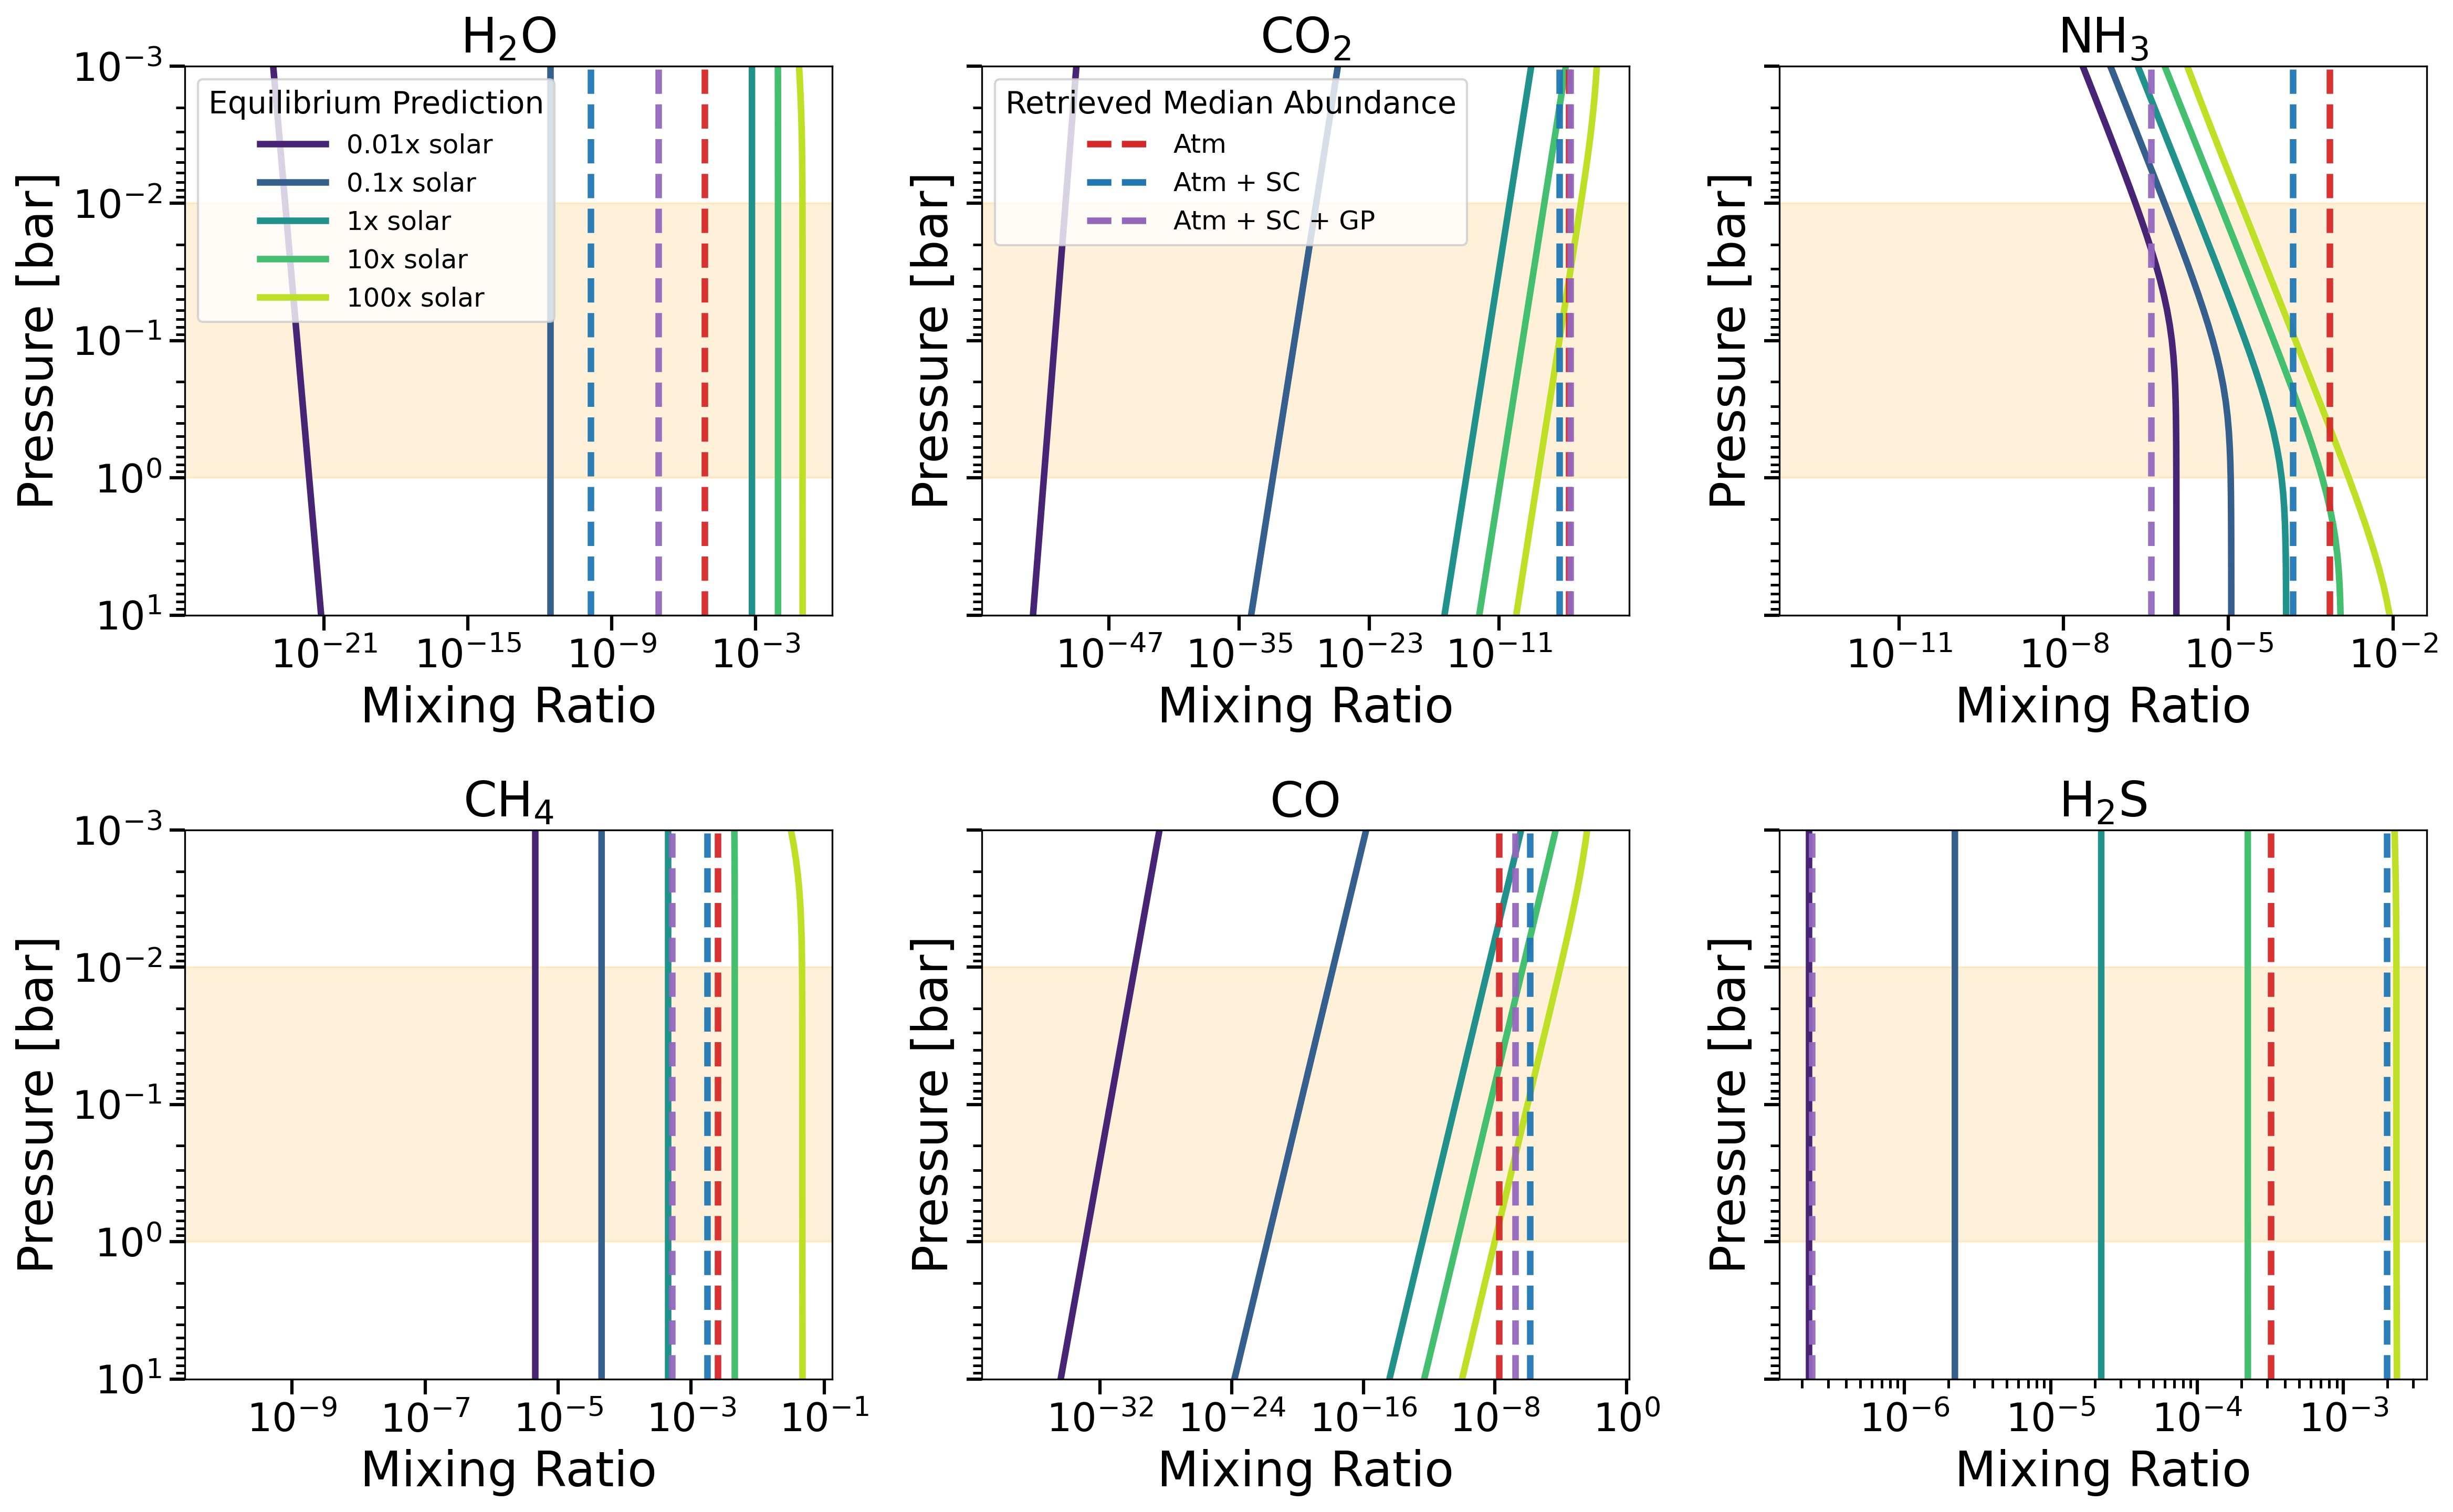

In [4]:
plt.rcParams.update({'font.size': 20, 'axes.titlesize': 22, 'axes.labelsize': 22,
                     'xtick.labelsize': 18, 'ytick.labelsize': 18, 'legend.fontsize': 15})

species_labels = {'H2O': r'H$_2$O', 'CO2': r'CO$_2$', 'NH3': r'NH$_3$', 'CH4': r'CH$_4$', 'CO': r'CO', 'H2S': r'H$_2$S'}
plot_species = ['H2O', 'CO2', 'NH3', 'CH4', 'CO', 'H2S']

fig, axes = plt.subplots(2, 3, figsize=(16, 10), sharey=True, dpi=300)
axes = axes.flatten()

for i, species in enumerate(plot_species):
    ax = axes[i]
    idx = species_idx[species]
    
    for j, met in enumerate(metallicities):
        data = data_all[met]
        pressure_bar = data['atm']['pco'] / 1e6
        mixing_ratio = data['variable']['ymix'][:, idx]
        ax.loglog(mixing_ratio, pressure_bar, color=colors[j], linewidth=3)
    
    for retrieval_name, abundance_dict in retrieval_abundances.items():
        samples = abundance_dict[species]
        samples = samples[np.isfinite(samples) & (samples > 0)]
        if len(samples) > 0:
            ax.axvline(np.median(samples), color=retrieval_colors[retrieval_name], linestyle='--', linewidth=3, alpha=0.95)
    
    ax.set_ylim(10, 1e-3)
    ax.set_xlabel('Mixing Ratio')
    ax.set_ylabel('Pressure [bar]')
    ax.set_title(species_labels[species], fontweight='normal')
    ax.axhspan(1e-2, 1e0, alpha=0.15, color='orange')
    ax.grid(False)
    ax.tick_params(axis='both', which='major', labelsize=18, length=7, width=1.5)
    ax.tick_params(axis='both', which='minor', labelsize=16, length=4, width=1.2)

eq_handles = [Line2D([0], [0], color=colors[j], linewidth=3, label=f'{met}x solar') for j, met in enumerate(metallicities)]
retrieval_handles = [Line2D([0], [0], color=c, linestyle='--', linewidth=3, label=n) for n, c in retrieval_colors.items()]

axes[0].legend(handles=eq_handles, loc='upper left', frameon=True, title='Equilibrium Prediction', title_fontsize=14, fontsize=12, handlelength=2.5)
axes[1].legend(handles=retrieval_handles, loc='upper left', frameon=True, title='Retrieved Median Abundance', title_fontsize=14, fontsize=12, handlelength=2.5)

plt.tight_layout()
plt.show()

## Figure 6

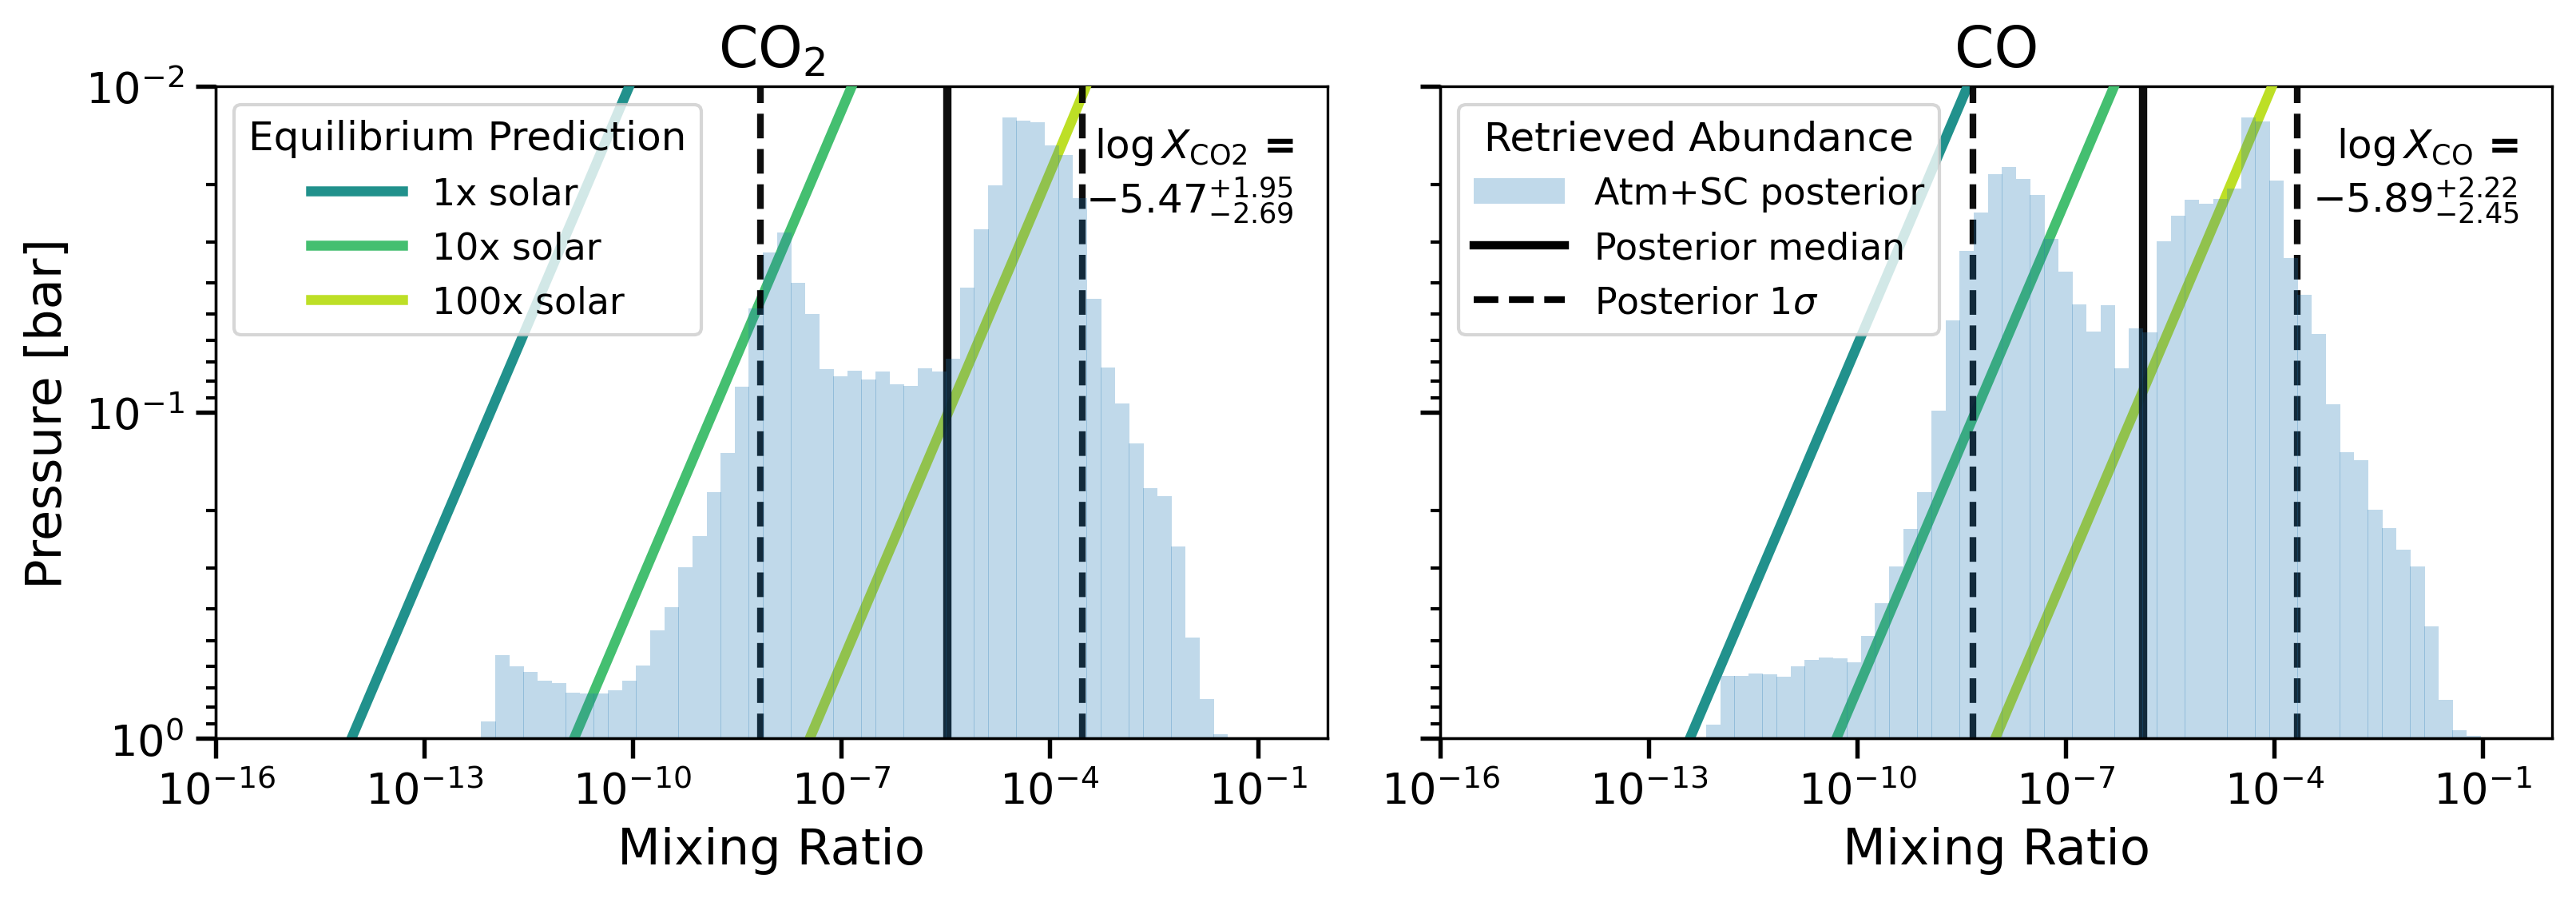

In [5]:
atm_sc_posteriors = {'CO2': CO2_atm_sc, 'CO': CO_atm_sc}

plt.rcParams.update({'font.size': 15, 'axes.titlesize': 17, 'axes.labelsize': 15,
                     'xtick.labelsize': 13, 'ytick.labelsize': 13, 'legend.fontsize': 12})

species_labels = {'CO2': r'CO$_2$', 'CO': r'CO'}
plot_species = ['CO2', 'CO']
posterior_color = 'tab:blue'
metallicities_to_plot = [met for met in metallicities if met not in [0.01, 0.1]]

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True, dpi=300)

for i, species in enumerate(plot_species):
    ax = axes[i]
    idx_species = species_idx[species]
    
    for met in metallicities_to_plot:
        j = list(metallicities).index(met)
        data = data_all[met]
        pressure_bar = data['atm']['pco'] / 1e6
        mixing_ratio = data['variable']['ymix'][:, idx_species]
        ax.loglog(mixing_ratio, pressure_bar, color=colors[j], linewidth=3, zorder=3)
    
    samples = atm_sc_posteriors[species]
    samples = samples[np.isfinite(samples) & (samples > 0)]
    
    ax_hist = ax.twinx()
    ax_hist.set_xscale('log')
    log_samples = np.log10(samples)
    bins_log = np.linspace(-15, 0, 75)
    hist, bin_edges_log = np.histogram(log_samples, bins=bins_log, density=True)
    bin_centers = 10**(0.5 * (bin_edges_log[:-1] + bin_edges_log[1:]))
    bin_widths = 10**bin_edges_log[1:] - 10**bin_edges_log[:-1]
    ax_hist.bar(bin_centers, hist, width=bin_widths, align="center", color=posterior_color, alpha=0.28, edgecolor="none", zorder=1)
    
    median_log = np.median(log_samples)
    p16_log, p84_log = np.percentile(log_samples, 16), np.percentile(log_samples, 84)
    ax.axvline(10**median_log, color="black", linestyle="-", linewidth=2.5, alpha=0.95, zorder=6)
    ax.axvline(10**p16_log, color="black", linestyle="--", linewidth=2.0, alpha=0.95, zorder=6)
    ax.axvline(10**p84_log, color="black", linestyle="--", linewidth=2.0, alpha=0.95, zorder=6)
    
    abundance_text = rf"$\log X_{{\mathrm{{{species}}}}}$ =" + "\n" + rf"${median_log:.2f}^{{+{p84_log-median_log:.2f}}}_{{{p16_log-median_log:.2f}}}$"
    ax.text(0.97, 0.94, abundance_text, transform=ax.transAxes, ha="right", va="top", color="black", fontsize=12, fontweight="bold")
    
    ax_hist.set_yticks([])
    ax_hist.spines['right'].set_visible(False)
    ax_hist.spines['top'].set_visible(False)
    ax_hist.grid(False)
    ax_hist.set_xlim(1e-16, 1)
    
    ax.set_ylim(1e0, 1e-2)
    ax.set_xlim(1e-16, 1)
    ax.set_xlabel('Mixing Ratio', fontsize=15)
    ax.set_title(species_labels[species], fontsize=17, fontweight='normal')
    ax.set_ylabel('Pressure [bar]' if i == 0 else '', fontsize=15)
    ax.grid(False)
    ax.tick_params(axis='both', which='major', labelsize=13, length=6, width=1.3)
    ax.tick_params(axis='both', which='minor', labelsize=13, length=3, width=1.0)

eq_handles = [Line2D([0], [0], color=colors[list(metallicities).index(met)], linewidth=3, label=f'{met}x solar') for met in metallicities_to_plot]
posterior_handles = [Patch(facecolor=posterior_color, alpha=0.28, label='Atm+SC posterior'),
                     Line2D([0], [0], color="black", linestyle="-", linewidth=2.5, label='Posterior median'),
                     Line2D([0], [0], color="black", linestyle="--", linewidth=2.0, label=r'Posterior $1\sigma$')]

axes[0].legend(handles=eq_handles, loc='upper left', frameon=True, title='Equilibrium Prediction', title_fontsize=12, fontsize=11, handlelength=2.5)
axes[1].legend(handles=posterior_handles, loc='upper left', frameon=True, title='Retrieved Abundance', title_fontsize=12, fontsize=11, handlelength=2.5)

plt.tight_layout()
plt.show()